# 📉 Customer Churn — Exploratory Data Analysis
> **Goal:** Explore client and pricing data to understand the patterns and factors associated with customer churn in an energy company.

---

## 📦 Section 1 — Import Libraries
We load the essential libraries for data exploration and visualisation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Show all columns without truncation
pd.set_option('display.max_columns', None)

# Set a clean white grid background for all plots
sns.set_style('whitegrid')

## 📂 Section 2 — Load Datasets
This project uses two datasets:
- **client_data.csv** — customer information and churn status
- **price_data.csv** — historical energy pricing data

In [3]:
# Load client data (customer demographics and churn labels)
client_df = pd.read_csv('forage/client_data (1).csv')

# Load price data (energy pricing history per customer)
price_df = pd.read_csv('forage/price_data (1).csv')

In [4]:
price_df.head()

,id,price_date,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix
0,038af19179925da21a25619c5a24b745,2015-01-01,0.151367,0.0,0.0,44.266931,0.0,0.0
1,038af19179925da21a25619c5a24b745,2015-02-01,0.151367,0.0,0.0,44.266931,0.0,0.0
2,038af19179925da21a25619c5a24b745,2015-03-01,0.151367,0.0,0.0,44.266931,0.0,0.0
3,038af19179925da21a25619c5a24b745,2015-04-01,0.149626,0.0,0.0,44.266931,0.0,0.0
4,038af19179925da21a25619c5a24b745,2015-05-01,0.149626,0.0,0.0,44.266931,0.0,0.0


In [5]:
client_df.head()

,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,forecast_cons_year,forecast_discount_energy,forecast_meter_rent_12m,forecast_price_energy_off_peak,forecast_price_energy_peak,forecast_price_pow_off_peak,has_gas,imp_cons,margin_gross_pow_ele,margin_net_pow_ele,nb_prod_act,net_margin,num_years_antig,origin_up,pow_max,churn
0,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.00,0,0.0,1.78,0.114481,0.098142,40.606701,t,0.00,25.44,25.44,2,678.99,3,lxidpiddsbxsbosboudacockeimpuepw,43.648,1
1,d29c2c54acc38ff3c0614d0a653813dd,MISSING,4660,0,0,2009-08-21,2016-08-30,2009-08-21,2015-08-31,189.95,0,0.0,16.27,0.145711,0.000000,44.311378,f,0.00,16.38,16.38,1,18.89,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.800,0
2,764c75f661154dac3a6c254cd082ea7d,foosdfpfkusacimwkcsosbicdxkicaua,544,0,0,2010-04-16,2016-04-16,2010-04-16,2015-04-17,47.96,0,0.0,38.72,0.165794,0.087899,44.311378,f,0.00,28.60,28.60,1,6.60,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.856,0
3,bba03439a292a1e166f80264c16191cb,lmkebamcaaclubfxadlmueccxoimlema,1584,0,0,2010-03-30,2016-03-30,2010-03-30,2015-03-31,240.04,0,0.0,19.83,0.146694,0.000000,44.311378,f,0.00,30.22,30.22,1,25.46,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.200,0
4,149d57cf92fc41cf94415803a877cb4b,MISSING,4425,0,526,2010-01-13,2016-03-07,2010-01-13,2015-03-09,445.75,526,0.0,131.73,0.116900,0.100015,40.606701,f,52.32,44.91,44.91,1,47.98,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,19.800,0


## 🔍 Section 3 — Data Overview & Types
Understanding column types is critical — it determines how we transform and use each variable.

In [8]:
# Overview of column names, data types, and non-null counts for client data
client_df.info()

print("==" *40)
price_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14606 entries, 0 to 14605
Data columns (total 26 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              14606 non-null  object 
 1   channel_sales                   14606 non-null  object 
 2   cons_12m                        14606 non-null  int64  
 3   cons_gas_12m                    14606 non-null  int64  
 4   cons_last_month                 14606 non-null  int64  
 5   date_activ                      14606 non-null  object 
 6   date_end                        14606 non-null  object 
 7   date_modif_prod                 14606 non-null  object 
 8   date_renewal                    14606 non-null  object 
 9   forecast_cons_12m               14606 non-null  float64
 10  forecast_cons_year              14606 non-null  int64  
 11  forecast_discount_energy        14606 non-null  float64
 12  forecast_meter_rent_12m         

## 📊 Section 4 — Descriptive Statistics
Summary statistics reveal the range, central tendency, and spread of each numeric column.

In [10]:
print("Client Data — Summary Statistics:")
client_df.describe()

Client Data — Summary Statistics:


,cons_12m,cons_gas_12m,cons_last_month,forecast_cons_12m,forecast_cons_year,forecast_discount_energy,forecast_meter_rent_12m,forecast_price_energy_off_peak,forecast_price_energy_peak,forecast_price_pow_off_peak,imp_cons,margin_gross_pow_ele,margin_net_pow_ele,nb_prod_act,net_margin,num_years_antig,pow_max,churn
count,1.460600e+04,1.460600e+04,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000
mean,1.592203e+05,2.809238e+04,16090.269752,1868.614880,1399.762906,0.966726,63.086871,0.137283,0.050491,43.130056,152.786896,24.565121,24.562517,1.292346,189.264522,4.997809,18.135136,0.097152
std,5.734653e+05,1.629731e+05,64364.196422,2387.571531,3247.786255,5.108289,66.165783,0.024623,0.049037,4.485988,341.369366,20.231172,20.230280,0.709774,311.798130,1.611749,13.534743,0.296175
min,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,3.300000,0.000000
25%,5.674750e+03,0.000000e+00,0.000000,494.995000,0.000000,0.000000,16.180000,0.116340,0.000000,40.606701,0.000000,14.280000,14.280000,1.000000,50.712500,4.000000,12.500000,0.000000
50%,1.411550e+04,0.000000e+00,792.500000,1112.875000,314.000000,0.000000,18.795000,0.143166,0.084138,44.311378,37.395000,21.640000,21.640000,1.000000,112.530000,5.000000,13.856000,0.000000
75%,4.076375e+04,0.000000e+00,3383.000000,2401.790000,1745.750000,0.000000,131.030000,0.146348,0.098837,44.311378,193.980000,29.880000,29.880000,1.000000,243.097500,6.000000,19.172500,0.000000
max,6.207104e+06,4.154590e+06,771203.000000,82902.830000,175375.000000,30.000000,599.310000,0.273963,0.195975,59.266378,15042.790000,374.640000,374.640000,32.000000,24570.650000,13.000000,320.000000,1.000000


In [12]:
print("==" *40)
print("\nPrice Data — Summary Statistics:")
price_df.describe()


Price Data — Summary Statistics:


,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix
count,193002.000000,193002.000000,193002.000000,193002.000000,193002.000000,193002.000000
mean,0.141027,0.054630,0.030496,43.334477,10.622875,6.409984
std,0.025032,0.049924,0.036298,5.410297,12.841895,7.773592
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.125976,0.000000,0.000000,40.728885,0.000000,0.000000
50%,0.146033,0.085483,0.000000,44.266930,0.000000,0.000000
75%,0.151635,0.101673,0.072558,44.444710,24.339581,16.226389
max,0.280700,0.229788,0.114102,59.444710,36.490692,17.458221


## 🔢 Section 5 — Unique Value Counts
Checking unique values per column helps identify categorical variables and potential data quality issues.

In [16]:
print("Unique value counts per column (Client Data):")
for col in client_df.columns:
    print(f"  {col}: {client_df[col].nunique()} unique values")

Unique value counts per column (Client Data):
  id: 14606 unique values
  channel_sales: 8 unique values
  cons_12m: 11065 unique values
  cons_gas_12m: 2112 unique values
  cons_last_month: 4751 unique values
  date_activ: 1796 unique values
  date_end: 368 unique values
  date_modif_prod: 2129 unique values
  date_renewal: 386 unique values
  forecast_cons_12m: 13993 unique values
  forecast_cons_year: 4218 unique values
  forecast_discount_energy: 12 unique values
  forecast_meter_rent_12m: 3528 unique values
  forecast_price_energy_off_peak: 516 unique values
  forecast_price_energy_peak: 329 unique values
  forecast_price_pow_off_peak: 41 unique values
  has_gas: 2 unique values
  imp_cons: 7752 unique values
  margin_gross_pow_ele: 2391 unique values
  margin_net_pow_ele: 2391 unique values
  nb_prod_act: 10 unique values
  net_margin: 11965 unique values
  num_years_antig: 13 unique values
  origin_up: 6 unique values
  pow_max: 698 unique values
  churn: 2 unique values


## ❓ Section 6 — Missing Value Check
Knowing where data is missing guides our cleaning strategy.

In [17]:
print("Missing Values — Client Data:")
print(client_df.isnull().sum())

print("\nMissing Values — Price Data:")
print(price_df.isnull().sum())

Missing Values — Client Data:
id                                0
channel_sales                     0
cons_12m                          0
cons_gas_12m                      0
cons_last_month                   0
date_activ                        0
date_end                          0
date_modif_prod                   0
date_renewal                      0
forecast_cons_12m                 0
forecast_cons_year                0
forecast_discount_energy          0
forecast_meter_rent_12m           0
forecast_price_energy_off_peak    0
forecast_price_energy_peak        0
forecast_price_pow_off_peak       0
has_gas                           0
imp_cons                          0
margin_gross_pow_ele              0
margin_net_pow_ele                0
nb_prod_act                       0
net_margin                        0
num_years_antig                   0
origin_up                         0
pow_max                           0
churn                             0
dtype: int64

Missing Values — Pri

## 📉 Section 7 — Churn Rate Visualisation
We visualise the overall churn rate using a stacked bar chart with percentage labels.

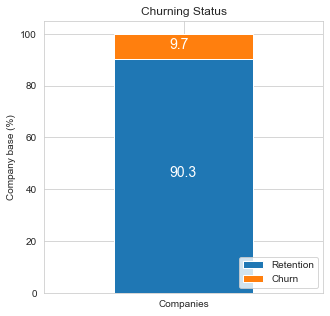

In [18]:
def plot_stacked_bars(dataframe, title_, size_=(18, 10), rot_=0, legend_='upper right'):
    """Plot stacked bars with percentage annotations."""
    ax = dataframe.plot(kind='bar', stacked=True, figsize=size_, rot=rot_, title=title_)
    annotate_stacked_bars(ax, textsize=14)
    plt.legend(['Retention', 'Churn'], loc=legend_)
    plt.ylabel('Company base (%)')
    plt.show()

def annotate_stacked_bars(ax, pad=0.99, colour='white', textsize=13):
    """Add percentage labels to the interior of each stacked bar segment."""
    for p in ax.patches:
        value = str(round(p.get_height(), 1))
        if value == '0.0':
            continue
        ax.annotate(
            value,
            ((p.get_x() + p.get_width() / 2) * pad - 0.05,
             (p.get_y() + p.get_height() / 2) * pad),
            color=colour,
            size=textsize
        )

# Compute churn breakdown as percentages for the stacked chart
churn = client_df[['id', 'churn']].copy()
churn.columns = ['Companies', 'churn']
churn_total = churn.groupby('churn').count()
churn_percentage = churn_total / churn_total.sum() * 100

plot_stacked_bars(churn_percentage.transpose(), 'Churning Status', (5, 5), legend_='lower right')

## 📈 Section 8 — Numeric Feature Distributions
Histograms with KDE overlays give us a full picture of each numeric variable's distribution.

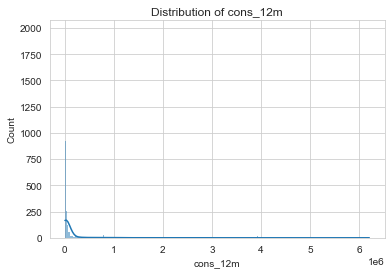

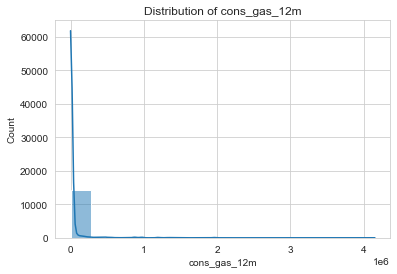

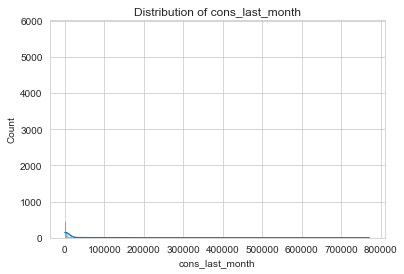

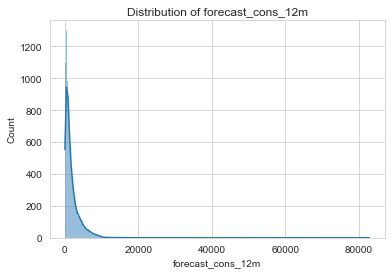

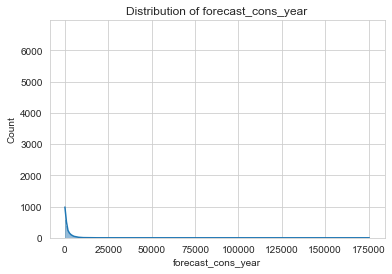

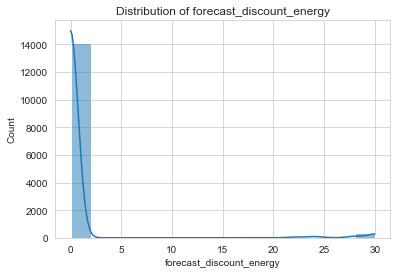

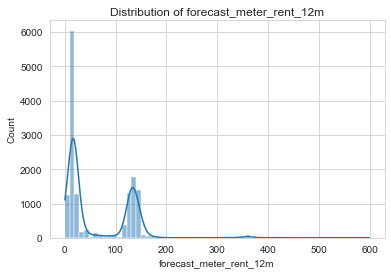

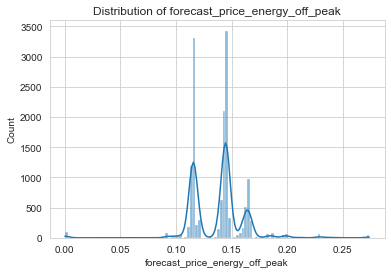

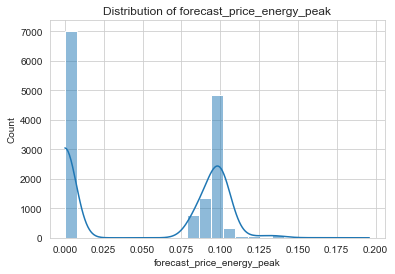

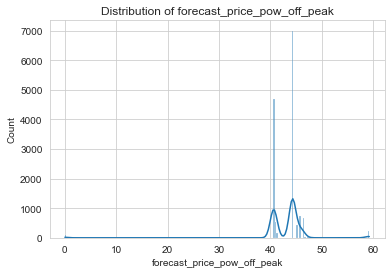

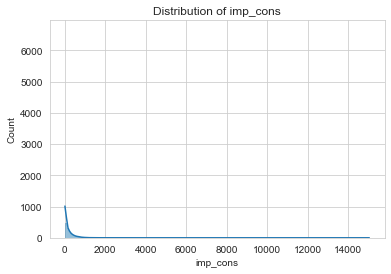

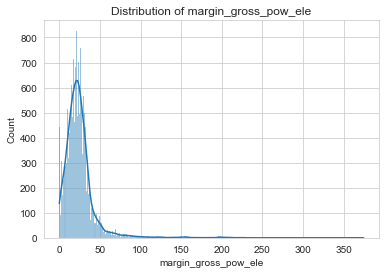

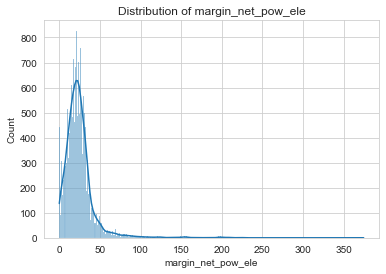

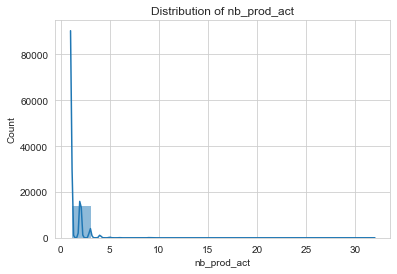

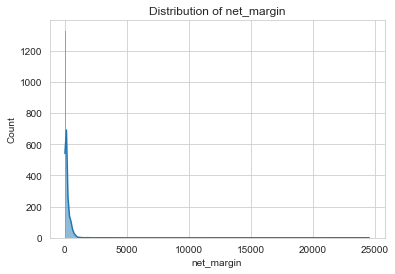

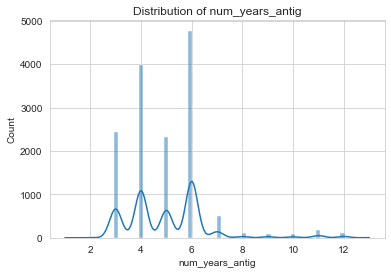

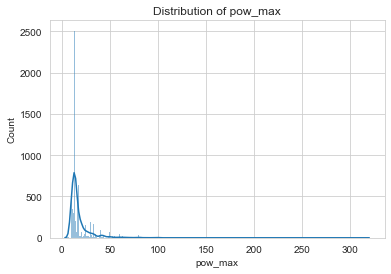

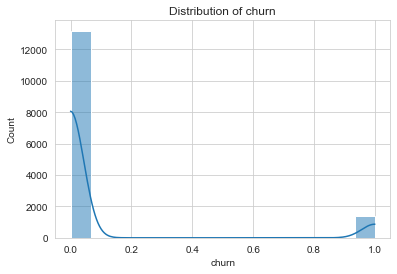

In [19]:
# Loop through all numeric columns and plot their distribution
num_cols = client_df.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    plt.figure()
    sns.histplot(client_df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

## 🏷️ Section 9 — Categorical Feature Distributions
Bar charts show the frequency of each category in the dataset's text-based columns.

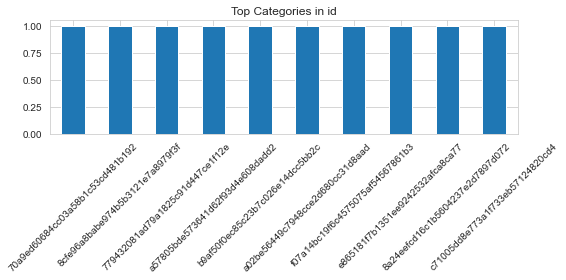

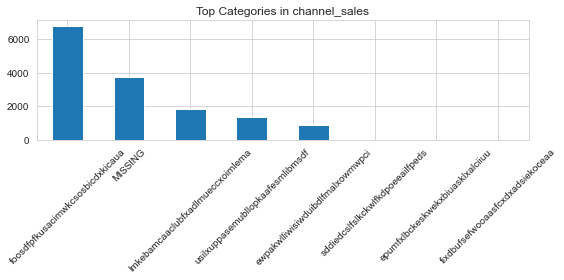

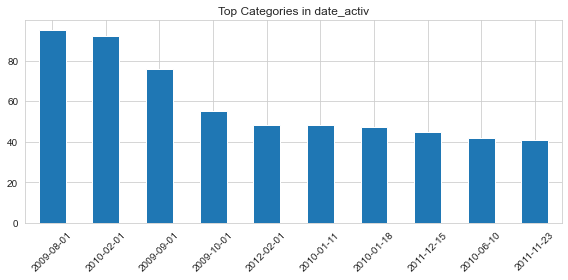

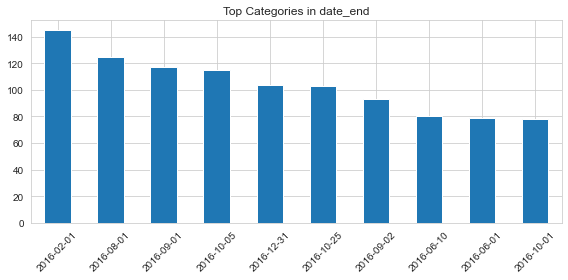

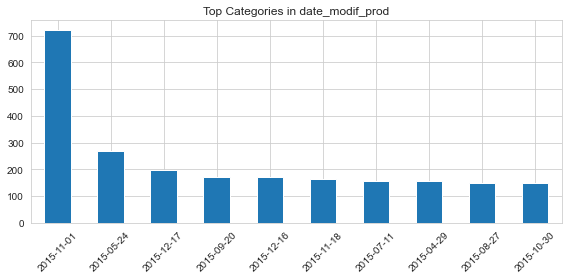

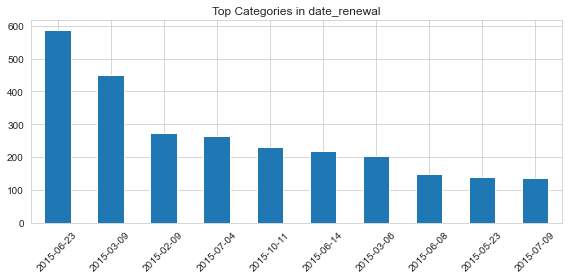

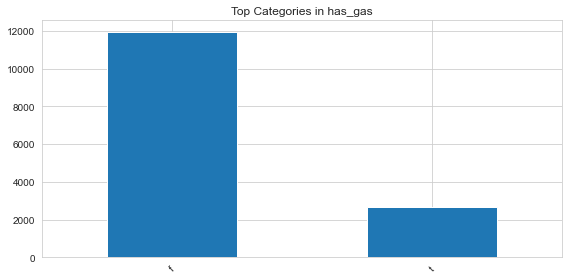

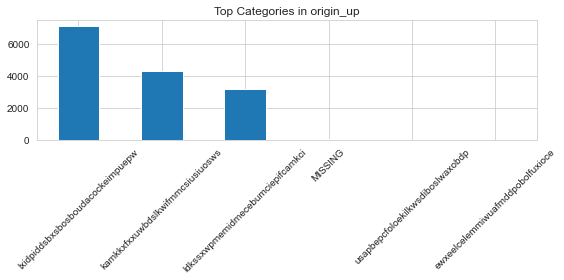

In [20]:
# Plot top 10 categories for each categorical (object-type) column
cat_cols = client_df.select_dtypes(include=['object']).columns

for col in cat_cols:
    plt.figure(figsize=(8, 4))
    client_df[col].value_counts().head(10).plot(kind='bar')
    plt.title(f'Top Categories in {col}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## 🔗 Section 10 — Correlation Heatmap
We visualise how all numeric features relate to each other — important for identifying multicollinearity.

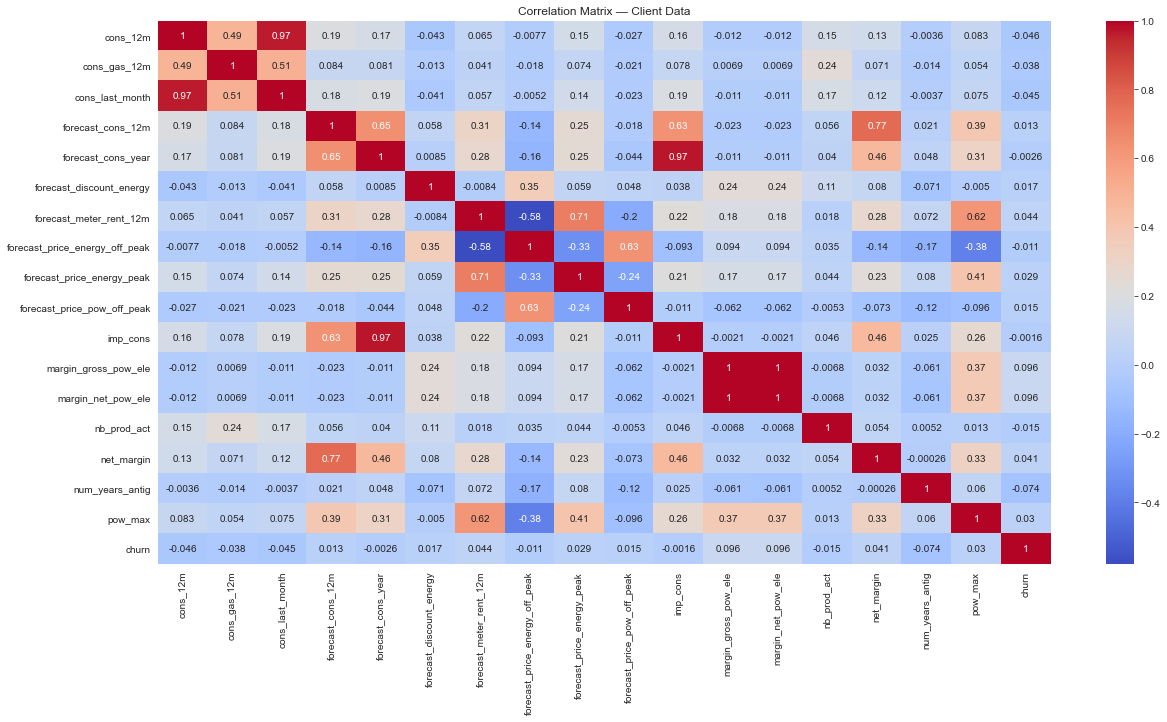

In [21]:
plt.figure(figsize=(20, 10))
sns.heatmap(client_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix — Client Data')
plt.show()

## 📊 Section 11 — Consumption Distribution by Churn Status
We compare energy consumption patterns between churned and retained customers.

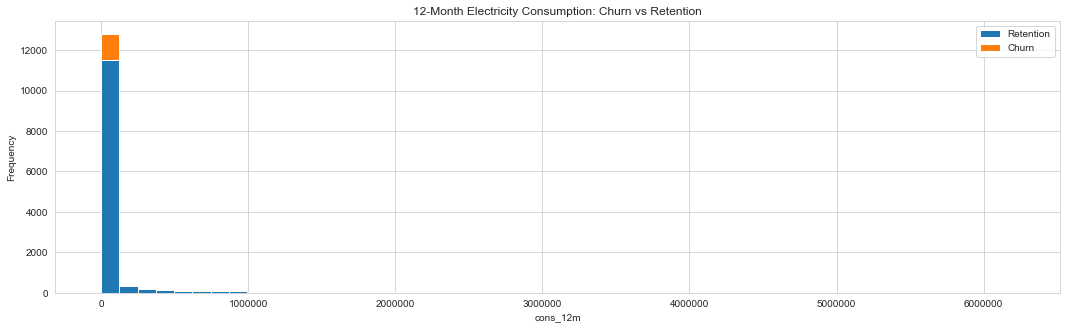

In [22]:
def plot_distribution(dataframe, column, ax, bins_=50):
    """Plot a stacked histogram comparing churned vs retained customers."""
    temp = pd.DataFrame({
        'Retention': dataframe[dataframe['churn'] == 0][column],
        'Churn':     dataframe[dataframe['churn'] == 1][column]
    })
    temp[['Retention', 'Churn']].plot(kind='hist', bins=bins_, ax=ax, stacked=True)
    ax.set_xlabel(column)
    ax.ticklabel_format(style='plain', axis='x')

# Compare 12-month electricity consumption for churned vs retained customers
consumption = client_df[['id', 'cons_12m', 'cons_gas_12m', 'cons_last_month', 'imp_cons', 'has_gas', 'churn']]
fig, axs = plt.subplots(nrows=1, figsize=(18, 5))
plot_distribution(consumption, 'cons_12m', axs)
plt.title('12-Month Electricity Consumption: Churn vs Retention')
plt.show()